# Final  Project

This notebook provides a complete Python solution for the project:
- measurement of task τ1;
- computation of Min, Max, Q1, Q2, Q3;
- selection of a WCET with a safety margin;
- construction of the task set;
- computation of utilization and hyperperiod;
- generation of jobs;
- search for a non-preemptive schedule at the job level;
- computation of waiting times, response times, and idle time;
- study of two cases:
  1. no missed deadlines allowed;
  2. one missed deadline allowed for τ5.

Assumptions:
 - all time values are expressed in milliseconds;
 - implicit deadlines: D_i = T_i ;
 - single-core processor;
 - non-preemptive scheduling;
 - the study is carried out over one hyperperiod.  

## 1. Imports

In [1]:
import time
import random
import math
import statistics
from dataclasses import dataclass, field, replace
from typing import List, Optional, Callable, Tuple, Dict
from functools import reduce
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)

## 2. Parameters



In [2]:
RUNS = 1000
NUM_DIGITS = 2000
COUNT_NUMBERS = 2
WARMUP_RUNS = 20
SAFETY_FACTOR = 1.10
SEED = 42
random.seed(SEED)

## 3. Definition of the task τ1

Here, we measure the entire cost of the task: generation of large random numbers, conversion to integers, and then multiplication.

In [3]:
def task_tau1(num_digits: int = 2000, count_numbers: int = 2) -> int:
    """
    Generates count_numbers large random integers with num_digits digits, then computes their product.
    """
    numbers = []
    for _ in range(count_numbers):
        first_digit = str(random.randint(1, 9))
        other_digits = ''.join(str(random.randint(0, 9)) for _ in range(num_digits - 1))
        numbers.append(int(first_digit + other_digits))

    product = 1
    for n in numbers:
        product *= n
    return product

## 4. Measure of time of execution of τ1

In [4]:
def measure_tau1_execution_times(
    runs: int = RUNS,
    num_digits: int = NUM_DIGITS,
    count_numbers: int = COUNT_NUMBERS,
    warmup_runs: int = WARMUP_RUNS
) -> List[float]:
    """ Returns a list of execution times in milliseconds. """
    # Warm-up
    for _ in range(warmup_runs):
        task_tau1(num_digits=num_digits, count_numbers=count_numbers)

    times_ms = []
    for _ in range(runs):
        start = time.perf_counter()
        task_tau1(num_digits=num_digits, count_numbers=count_numbers)
        end = time.perf_counter()
        times_ms.append((end - start) * 1000.0)
    return times_ms

## 5. Statistics : Min, Max, Q1, Q2, Q3, mean, standard deviation

In [5]:
def percentile(sorted_values: List[float], p: float) -> float:
    if not sorted_values:
        raise ValueError("Empty list")
    if len(sorted_values) == 1:
        return sorted_values[0]

    pos = (len(sorted_values) - 1) * p
    lower = math.floor(pos)
    upper = math.ceil(pos)
    if lower == upper:
        return sorted_values[lower]
    weight = pos - lower
    return sorted_values[lower] * (1 - weight) + sorted_values[upper] * weight


def compute_statistics(times_ms: List[float]) -> Dict[str, float]:
    values = sorted(times_ms)
    return {
        "min_ms": values[0],
        "q1_ms": percentile(values, 0.25),
        "q2_ms": percentile(values, 0.50),
        "q3_ms": percentile(values, 0.75),
        "max_ms": values[-1],
        "mean_ms": statistics.mean(values),
        "stdev_ms": statistics.pstdev(values),
    }


def choose_c1_from_measurements(stats: Dict[str, float], safety_factor: float = SAFETY_FACTOR) -> float:
    """
   Selected WCET = observed maximum × safety factor.
    """
    return stats["max_ms"] * safety_factor


def print_statistics(stats: Dict[str, float], c1: float) -> None:
    print("Statistiques τ1")
    print(f"Min  : {stats['min_ms']:.6f} ms")
    print(f"Q1   : {stats['q1_ms']:.6f} ms")
    print(f"Q2   : {stats['q2_ms']:.6f} ms")
    print(f"Q3   : {stats['q3_ms']:.6f} ms")
    print(f"Max  : {stats['max_ms']:.6f} ms")
    print(f"Moy. : {stats['mean_ms']:.6f} ms")
    print(f"σ    : {stats['stdev_ms']:.6f} ms")
    print(f"C1 retenu (max × {SAFETY_FACTOR:.2f}) : {c1:.6f} ms")

## 6. Real measure of τ1

It generates the statistics, a histogram, and the selected value of C1.

Statistiques τ1
Min  : 3.281400 ms
Q1   : 4.250450 ms
Q2   : 5.997950 ms
Q3   : 7.365900 ms
Max  : 22.115000 ms
Moy. : 6.168975 ms
σ    : 2.381180 ms
C1 retenu (max × 1.10) : 24.326500 ms


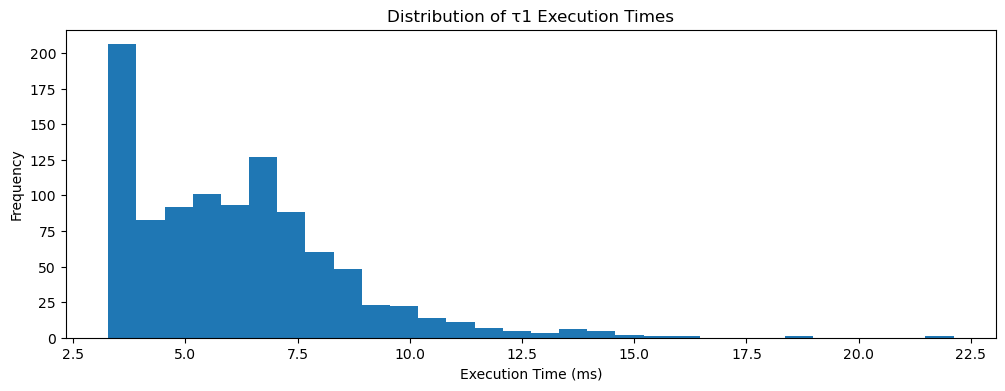

In [6]:
times_ms = measure_tau1_execution_times()
stats = compute_statistics(times_ms)
C1 = choose_c1_from_measurements(stats)

print_statistics(stats, C1)

plt.hist(times_ms, bins=30)
plt.xlabel("Execution Time (ms)")
plt.ylabel("Frequency")
plt.title("Distribution of τ1 Execution Times")
plt.show()

## 7. Modelisation du système temps réelof the real-time system
We take :
- \(D_i = T_i\) ;
- all values in **millisecondes** ;
- the task set given in the statement.

In [7]:
@dataclass
class Task:
    name: str
    C: float
    T: int
    D: Optional[int] = None

    def __post_init__(self):
        if self.D is None:
            self.D = self.T


def build_task_set(c1_value_ms: float) -> List[Task]:
    return [
        Task("τ1", c1_value_ms, 10),
        Task("τ2", 3.0, 10),
        Task("τ3", 2.0, 20),
        Task("τ4", 2.0, 20),
        Task("τ5", 2.0, 40),
        Task("τ6", 2.0, 40),
        Task("τ7", 3.0, 80),
    ]


tasks = build_task_set(C1)
pd.DataFrame([{"Task": t.name, "C (ms)": t.C, "T (ms)": t.T, "D (ms)": t.D} for t in tasks])

,Task,C (ms),T (ms),D (ms)
0,τ1,24.3265,10,10
1,τ2,3.0000,10,10
2,τ3,2.0000,20,20
3,τ4,2.0000,20,20
4,τ5,2.0000,40,40
5,τ6,2.0000,40,40
6,τ7,3.0000,80,80


## 8. CPU utilisation and an initial schedulability check

Reminder :
\[
U = \sum_i \frac{C_i}{T_i}
\]

- if \(U > 1\), the system is necessarily not schedulable;
- if \(U \le 1\), it may be schedulable, but this must be confirmed by a detailed job-level analysis.

In [8]:
def utilization(tasks: List[Task]) -> float:
    return sum(task.C / task.T for task in tasks)


u_total = utilization(tasks)
u_df = pd.DataFrame(
    [{"Task": t.name, "Ui = C/T": t.C / t.T} for t in tasks] + [{"Task": "Total", "Ui = C/T": u_total}]
)
u_df

,Task,Ui = C/T
0,τ1,2.43265
1,τ2,0.30000
2,τ3,0.10000
3,τ4,0.10000
4,τ5,0.05000
5,τ6,0.05000
6,τ7,0.03750
7,Total,3.07015


## 9. Hyperperiod

In [9]:
def lcm(a: int, b: int) -> int:
    return abs(a * b) // math.gcd(a, b)


def hyperperiod(tasks: List[Task]) -> int:
    return reduce(lcm, [task.T for task in tasks], 1)


HP = hyperperiod(tasks)
print("Hyperperiod =", HP, "ms")

Hyperperiod = 80 ms


## 10. Job generation over (0, hyperperiod)

In [10]:
@dataclass
class Job:
    task_name: str
    job_id: int
    release: float
    deadline: float
    execution: float
    start: Optional[float] = None
    finish: Optional[float] = None
    waiting: Optional[float] = None
    response_time: Optional[float] = None
    missed_deadline: Optional[bool] = None


def generate_jobs(tasks: List[Task], hp: int) -> List[Job]:
    jobs: List[Job] = []
    for task in tasks:
        num_jobs = hp // task.T
        for k in range(num_jobs):
            release = k * task.T
            jobs.append(
                Job(
                    task_name=task.name,
                    job_id=k + 1,
                    release=release,
                    deadline=release + task.D,
                    execution=task.C,
                )
            )
    jobs.sort(key=lambda j: (j.release, j.deadline, j.task_name, j.job_id))
    return jobs


jobs = generate_jobs(tasks, HP)
print("Number of jobs :", len(jobs))
pd.DataFrame([job.__dict__ for job in jobs]).head(15)

Number of jobs : 29


,task_name,job_id,release,deadline,execution,start,finish,waiting,response_time,missed_deadline
0,τ1,1,0,10,24.3265,None,None,None,None,None
1,τ2,1,0,10,3.0000,None,None,None,None,None
2,τ3,1,0,20,2.0000,None,None,None,None,None
3,τ4,1,0,20,2.0000,None,None,None,None,None
4,τ5,1,0,40,2.0000,None,None,None,None,None
5,τ6,1,0,40,2.0000,None,None,None,None,None
6,τ7,1,0,80,3.0000,None,None,None,None,None
7,τ1,2,10,20,24.3265,None,None,None,None,None
8,τ2,2,10,20,3.0000,None,None,None,None,None
9,τ1,3,20,30,24.3265,None,None,None,None,None


## 11. Utility functions for evaluating a schedule

In [11]:
def total_waiting_time(scheduled_jobs: List[Job]) -> float:
    return sum(job.waiting for job in scheduled_jobs if job.waiting is not None)


def total_idle_time(scheduled_jobs: List[Job]) -> float:
    if not scheduled_jobs:
        return 0.0

    idle = 0.0
    current = 0.0
    for job in scheduled_jobs:
        if job.start > current:
            idle += job.start - current
        current = job.finish
    return idle


def deadline_misses(scheduled_jobs: List[Job], allow_tau5_miss: bool = False) -> List[Job]:
    bad = []
    for job in scheduled_jobs:
        if job.missed_deadline:
            if allow_tau5_miss and job.task_name == "τ5":
                continue
            bad.append(job)
    return bad


def is_feasible(scheduled_jobs: List[Job], allow_tau5_miss: bool = False) -> bool:
    return len(deadline_misses(scheduled_jobs, allow_tau5_miss=allow_tau5_miss)) == 0

## 12. Search for a non-preemptive schedule

Here, we test several greedy heuristics at the job level, then keep the best feasible solution according to:

1. feasibility;
2. lowest total waiting time;
3. greatest idle time in case of a tie.

This approach is reasonable for a project notebook: it is more robust than using a single heuristic, while remaining simple to explain in the report.

In [12]:
def clone_jobs(jobs: List[Job]) -> List[Job]:
    return [replace(j) for j in jobs]


def score_ready_job(job: Job, now: float, rule: str) -> Tuple:
    slack = job.deadline - (now + job.execution)
    if rule == "edf":
        return (job.deadline, job.release, job.execution, job.task_name, job.job_id)
    elif rule == "spt":
        return (job.execution, job.deadline, job.release, job.task_name, job.job_id)
    elif rule == "slack":
        return (slack, job.deadline, job.execution, job.release, job.task_name, job.job_id)
    elif rule == "release_then_deadline":
        return (job.release, job.deadline, job.execution, job.task_name, job.job_id)
    elif rule == "deadline_then_spt":
        return (job.deadline, job.execution, job.release, job.task_name, job.job_id)
    else:
        raise ValueError(f"Règle inconnue: {rule}")


def schedule_non_preemptive(jobs: List[Job], rule: str, allow_tau5_miss: bool = False) -> List[Job]:
    unscheduled = clone_jobs(jobs)
    scheduled: List[Job] = []
    now = 0.0

    while unscheduled:
        ready = [j for j in unscheduled if j.release <= now]

        if not ready:
            now = min(j.release for j in unscheduled)
            ready = [j for j in unscheduled if j.release <= now]

        ready.sort(key=lambda j: score_ready_job(j, now, rule))

        chosen = None
        # We first try to find a job that does not violate the current feasibility rule.
        for candidate in ready:
            finish = now + candidate.execution
            miss = finish > candidate.deadline
            if miss and not (allow_tau5_miss and candidate.task_name == "τ5"):
                continue
            chosen = candidate
            break

        # if no "allowed" job is found, we take the best one according to the rule
        if chosen is None:
            chosen = ready[0]

        chosen.start = now
        chosen.finish = now + chosen.execution
        chosen.waiting = chosen.start - chosen.release
        chosen.response_time = chosen.finish - chosen.release
        chosen.missed_deadline = chosen.finish > chosen.deadline

        scheduled.append(chosen)
        unscheduled.remove(chosen)
        now = chosen.finish

    return scheduled


def evaluate_schedule(schedule: List[Job], allow_tau5_miss: bool = False) -> Dict[str, float]:
    misses = deadline_misses(schedule, allow_tau5_miss=allow_tau5_miss)
    return {
        "feasible": len(misses) == 0,
        "num_misses": len(misses),
        "total_waiting": total_waiting_time(schedule),
        "total_idle": total_idle_time(schedule),
        "max_response_time": max(job.response_time for job in schedule),
    }


def find_best_schedule(jobs: List[Job], allow_tau5_miss: bool = False):
    rules = ["edf", "deadline_then_spt", "slack", "spt", "release_then_deadline"]
    results = []

    for rule in rules:
        schedule = schedule_non_preemptive(jobs, rule=rule, allow_tau5_miss=allow_tau5_miss)
        metrics = evaluate_schedule(schedule, allow_tau5_miss=allow_tau5_miss)
        results.append((rule, schedule, metrics))

    # priority: feasibility, then smallest waiting time, then largest idle time
    results.sort(
        key=lambda x: (
            0 if x[2]["feasible"] else 1,
            x[2]["total_waiting"],
            -x[2]["total_idle"],
            x[2]["num_misses"],
        )
    )
    return results[0], results

## 13. Case 1 — no missed deadlines allowed

In [13]:
(best_case1, all_case1) = find_best_schedule(jobs, allow_tau5_miss=False)
best_rule_1, schedule_1, metrics_1 = best_case1

print("Best rule (case 1) :", best_rule_1)
print(metrics_1)

comparison_case1 = pd.DataFrame(
    [{"rule": rule, **metrics} for rule, _, metrics in all_case1]
).sort_values(["feasible", "total_waiting", "total_idle"], ascending=[False, True, False])
comparison_case1

Best rule (case 1) : spt
{'feasible': False, 'num_misses': 14, 'total_waiting': 1002.712999988813, 'total_idle': 0.0, 'max_response_time': 175.61199999786913}


,rule,feasible,num_misses,total_waiting,total_idle,max_response_time
0,spt,False,14,1002.7130,0.0,175.612
1,release_then_deadline,False,16,1675.5080,0.0,175.612
2,edf,False,16,1676.5080,0.0,175.612
3,deadline_then_spt,False,16,1676.5080,0.0,175.612
4,slack,False,16,2051.0585,0.0,185.612


## 14. Case 2 — one missed deadline allowed for τ5

In [14]:
(best_case2, all_case2) = find_best_schedule(jobs, allow_tau5_miss=True)
best_rule_2, schedule_2, metrics_2 = best_case2

print("Best rule (case 2) :", best_rule_2)
print(metrics_2)

comparison_case2 = pd.DataFrame(
    [{"rule": rule, **metrics} for rule, _, metrics in all_case2]
).sort_values(["feasible", "total_waiting", "total_idle"], ascending=[False, True, False])
comparison_case2

Best rule (case 2) : spt
{'feasible': False, 'num_misses': 14, 'total_waiting': 1002.712999988813, 'total_idle': 0.0, 'max_response_time': 175.61199999786913}


,rule,feasible,num_misses,total_waiting,total_idle,max_response_time
0,spt,False,14,1002.7130,0.0,175.612
1,release_then_deadline,False,16,1675.5080,0.0,175.612
2,edf,False,16,1676.5080,0.0,175.612
3,deadline_then_spt,False,16,1676.5080,0.0,175.612
4,slack,False,16,2051.0585,0.0,185.612


## 15. Detailed job table — Case 1

In [15]:
df_schedule_1 = pd.DataFrame([job.__dict__ for job in schedule_1])
df_schedule_1

,task_name,job_id,release,deadline,execution,start,finish,waiting,response_time,missed_deadline
0,τ3,1,0,20,2.0000,0.0000,2.0000,0.0000,2.0000,False
1,τ4,1,0,20,2.0000,2.0000,4.0000,2.0000,4.0000,False
2,τ5,1,0,40,2.0000,4.0000,6.0000,4.0000,6.0000,False
3,τ6,1,0,40,2.0000,6.0000,8.0000,6.0000,8.0000,False
4,τ7,1,0,80,3.0000,8.0000,11.0000,8.0000,11.0000,False
5,τ2,2,10,20,3.0000,11.0000,14.0000,1.0000,4.0000,False
6,τ2,1,0,10,3.0000,14.0000,17.0000,14.0000,17.0000,True
7,τ1,1,0,10,24.3265,17.0000,41.3265,17.0000,41.3265,True
8,τ3,3,40,60,2.0000,41.3265,43.3265,1.3265,3.3265,False
9,τ4,3,40,60,2.0000,43.3265,45.3265,3.3265,5.3265,False


## 16. Detailed job table — Case 2

In [16]:
df_schedule_2 = pd.DataFrame([job.__dict__ for job in schedule_2])
df_schedule_2

,task_name,job_id,release,deadline,execution,start,finish,waiting,response_time,missed_deadline
0,τ3,1,0,20,2.0000,0.0000,2.0000,0.0000,2.0000,False
1,τ4,1,0,20,2.0000,2.0000,4.0000,2.0000,4.0000,False
2,τ5,1,0,40,2.0000,4.0000,6.0000,4.0000,6.0000,False
3,τ6,1,0,40,2.0000,6.0000,8.0000,6.0000,8.0000,False
4,τ7,1,0,80,3.0000,8.0000,11.0000,8.0000,11.0000,False
5,τ2,2,10,20,3.0000,11.0000,14.0000,1.0000,4.0000,False
6,τ2,1,0,10,3.0000,14.0000,17.0000,14.0000,17.0000,True
7,τ1,1,0,10,24.3265,17.0000,41.3265,17.0000,41.3265,True
8,τ3,3,40,60,2.0000,41.3265,43.3265,1.3265,3.3265,False
9,τ4,3,40,60,2.0000,43.3265,45.3265,3.3265,5.3265,False


## 17. Explicit verification of deadlines and response times

In [17]:
misses_case1 = pd.DataFrame([job.__dict__ for job in deadline_misses(schedule_1, allow_tau5_miss=False)])
misses_case2 = pd.DataFrame([job.__dict__ for job in deadline_misses(schedule_2, allow_tau5_miss=True)])

print("Case 1 feasible :", is_feasible(schedule_1, allow_tau5_miss=False))
print("Case 2 feasible (with τ5 allowed) :", is_feasible(schedule_2, allow_tau5_miss=True))

print("\n Missed Deadlines - case 1")
display(misses_case1 if not misses_case1.empty else pd.DataFrame({"info": ["None"]}))

print("\n Missed Deadlines - case 2")
display(misses_case2 if not misses_case2.empty else pd.DataFrame({"info": ["None"]}))

Case 1 feasible : False
Case 2 feasible (with τ5 allowed) : False

 Missed Deadlines - case 1


,task_name,job_id,release,deadline,execution,start,finish,waiting,response_time,missed_deadline
0,τ2,1,0,10,3.0000,14.0000,17.0000,14.0000,17.0000,True
1,τ1,1,0,10,24.3265,17.0000,41.3265,17.0000,41.3265,True
2,τ3,2,20,40,2.0000,49.3265,51.3265,29.3265,31.3265,True
3,τ4,2,20,40,2.0000,54.3265,56.3265,34.3265,36.3265,True
4,τ2,3,20,30,3.0000,56.3265,59.3265,36.3265,39.3265,True
5,τ2,4,30,40,3.0000,59.3265,62.3265,29.3265,32.3265,True
6,τ2,5,40,50,3.0000,69.3265,72.3265,29.3265,32.3265,True
7,τ1,2,10,20,24.3265,75.3265,99.6530,65.3265,89.6530,True
8,τ1,3,20,30,24.3265,99.6530,123.9795,79.6530,103.9795,True
9,τ1,4,30,40,24.3265,123.9795,148.3060,93.9795,118.3060,True



 Missed Deadlines - case 2


,task_name,job_id,release,deadline,execution,start,finish,waiting,response_time,missed_deadline
0,τ2,1,0,10,3.0000,14.0000,17.0000,14.0000,17.0000,True
1,τ1,1,0,10,24.3265,17.0000,41.3265,17.0000,41.3265,True
2,τ3,2,20,40,2.0000,49.3265,51.3265,29.3265,31.3265,True
3,τ4,2,20,40,2.0000,54.3265,56.3265,34.3265,36.3265,True
4,τ2,3,20,30,3.0000,56.3265,59.3265,36.3265,39.3265,True
5,τ2,4,30,40,3.0000,59.3265,62.3265,29.3265,32.3265,True
6,τ2,5,40,50,3.0000,69.3265,72.3265,29.3265,32.3265,True
7,τ1,2,10,20,24.3265,75.3265,99.6530,65.3265,89.6530,True
8,τ1,3,20,30,24.3265,99.6530,123.9795,79.6530,103.9795,True
9,τ1,4,30,40,24.3265,123.9795,148.3060,93.9795,118.3060,True


## 18. Synthetic comparaison between the two cases

In [18]:
summary = pd.DataFrame([
    {
        "Case": "Case 1 - no deadline missed",
        "Rule": best_rule_1,
        "Feaisable": metrics_1["feasible"],
        "Nb deadlines missed": metrics_1["num_misses"],
        "Waiting total (ms)": metrics_1["total_waiting"],
        "Idle total (ms)": metrics_1["total_idle"],
        "Max response time (ms)": metrics_1["max_response_time"],
    },
    {
        "Case": "Case 2 - τ5 can miss",
        "Rule": best_rule_2,
        "Feaisable": metrics_2["feasible"],
        "Nb deadlines missed": metrics_2["num_misses"],
        "Waiting total (ms)": metrics_2["total_waiting"],
        "Idle total (ms)": metrics_2["total_idle"],
        "Max response time (ms)": metrics_2["max_response_time"],
    }
])
summary

,Case,Rule,Feaisable,Nb deadlines missed,Waiting total (ms),Idle total (ms),Max response time (ms)
0,Case 1 - no deadline missed,spt,False,14,1002.713,0.0,175.612
1,Case 2 - τ5 can miss,spt,False,14,1002.713,0.0,175.612


## 19. Visualisation type Gantt

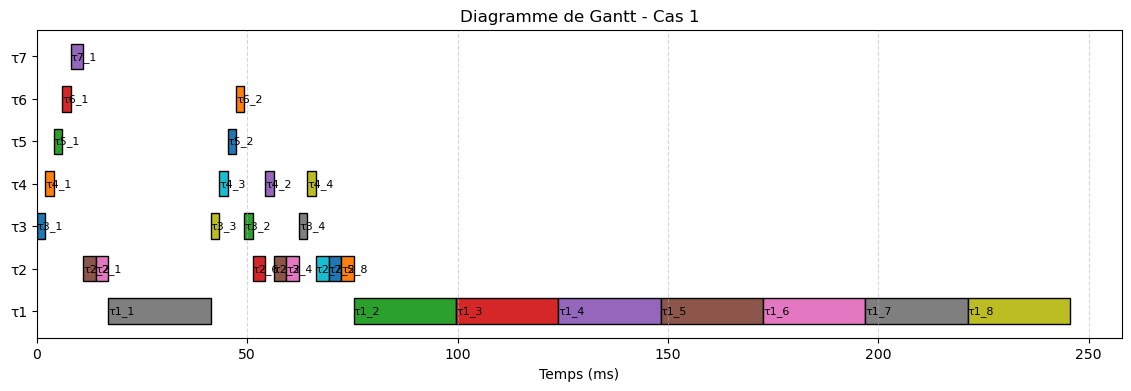

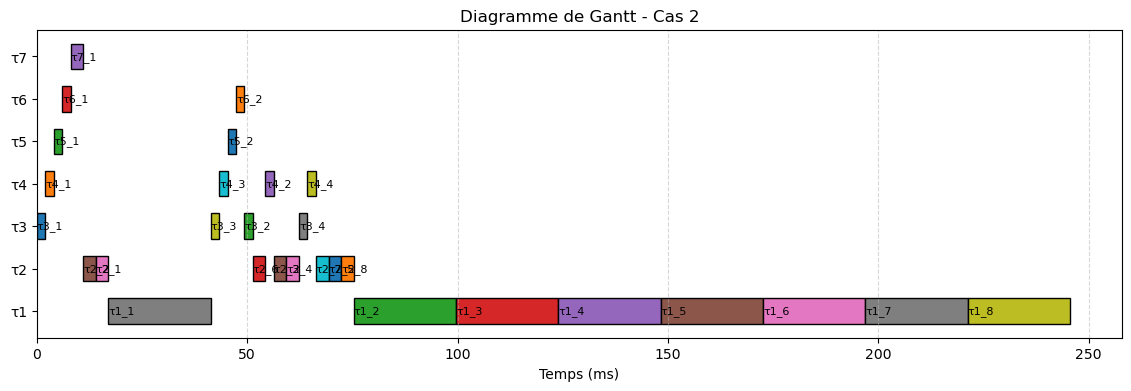

In [19]:
def plot_gantt(schedule: List[Job], title: str):
    fig, ax = plt.subplots(figsize=(14, 4))
    task_names = sorted(set(job.task_name for job in schedule))
    y_positions = {task: i for i, task in enumerate(task_names)}

    for job in schedule:
        y = y_positions[job.task_name]
        ax.barh(y, job.finish - job.start, left=job.start, height=0.6, edgecolor="black")
        ax.text(job.start, y, f"{job.task_name}_{job.job_id}", va="center", ha="left", fontsize=8)

    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_xlabel("Temps (ms)")
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    plt.show()


plot_gantt(schedule_1, "Diagramme de Gantt - Cas 1")
plot_gantt(schedule_2, "Diagramme de Gantt - Cas 2")

## 20. Automatic interpretation of the resultats


In [20]:
def interpretation_text(u_total, hp, metrics_1, metrics_2, best_rule_1, best_rule_2):
    txt = []
    txt.append(f"Utilisation totale U = {u_total:.6f}.")
    if u_total > 1:
        txt.append("Like U > 1, The system is a priori highly loaded; full feasibility must be verified at the job level.")
    else:
        txt.append("like U ≤ 1, The system is potentially schedulable; feasibility must still be confirmed at the job level.")

    txt.append(f"The hyperperiod is {hp} ms, which allows studying a complete execution pattern.")
    txt.append(f"In case 1, the best heuristic found is '{best_rule_1}' with total waiting = {metrics_1['total_waiting']:.6f} ms and total idle = {metrics_1['total_idle']:.6f} ms.")
    txt.append(f"In case 2, the best heuristic found is '{best_rule_2}' with total waiting = {metrics_2['total_waiting']:.6f} ms and total idle = {metrics_2['total_idle']:.6f} ms.")
    if metrics_2["total_waiting"] < metrics_1["total_waiting"]:
        txt.append("Allowing τ5 to miss a deadline improves the total waiting time.")
    elif metrics_2["total_waiting"] > metrics_1["total_waiting"]:
        txt.append("Allowing τ5 to miss a deadline does not improve the total waiting time.")
    else:
        txt.append("Both cases give the same total waiting time with this search strategy.")
    return "\n".join(txt)


print(interpretation_text(u_total, HP, metrics_1, metrics_2, best_rule_1, best_rule_2))

Utilisation totale U = 3.070150.
Like U > 1, The system is a priori highly loaded; full feasibility must be verified at the job level.
The hyperperiod is 80 ms, which allows studying a complete execution pattern.
In case 1, the best heuristic found is 'spt' with total waiting = 1002.713000 ms and total idle = 0.000000 ms.
In case 2, the best heuristic found is 'spt' with total waiting = 1002.713000 ms and total idle = 0.000000 ms.
Both cases give the same total waiting time with this search strategy.


## 21. Complexity of this approche

### Qualitative complexity
- Job generation : **O(N_j)**, where \(N_j\) is the total number of jobs over the hyperperiod.
- Initial sorting / comparisons: on the order of **O(N_j \log N_j)**.
- Each greedy heuristic scans the remaining jobs multiple times: approximately**O(N_j^2)**.
- Since several heuristics are tested, the overall complexity remains of the same order : **O(k N_j^2)** with \(k\) small and constant.

